In [20]:
# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# Model 구현
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

In [ ]:
# 1. Raw Data Loading
df = pd.read_csv('/content/train.csv')
# print(df.shape) # (891, 12)
display(df.head())

In [ ]:
# 필요없는 독립변수(Feature)가 있으면 일단 제거
df1 = df.drop(["PassengerId","Name", "Ticket", "Fare", "Cabin"],
              axis=1,
              inplace=False)
display(df1.head())

In [ ]:
# 각 컬럼의 상태를 확인
# df1.info()
# 성별부터 처리해 보아요 => 문자를 숫자로 변경
# male => 0, female => 1로 변경할 꺼예요!
gender_mapping = { "male": 0,
                   "female": 1}
df1['Sex'] = df1['Sex'].map(gender_mapping)
display(df1.head())

In [ ]:
# 의미가 유사한 SibSp와 Parch 컬럼을 합쳐서 하나의 컬럼으로
# 만들꺼예요(독립변수의 개수를 줄일 수 있어요!)
df1['Family'] = df1['SibSp'] + df1['Parch']
df2 = df1.drop(['SibSp', 'Parch'],
               axis=1,
               inplace=False)
display(df2.head())

In [25]:
# 결측치부터 처리하고 나머지 데이터를 손을 더 봐야해요!
# Embarked 안에 결측치가 2개 있어요!
# 수정해서 사용해요! (S, C, Q)
# 승선위치 값에 대한 빈도를 이용해서 빈도가 높은 값을 찾아서
# 결측치를 대체. => Q로 대체
df2['Embarked'] = df2['Embarked'].fillna('Q')
# 결측치가 다 채워졌으니 이제 숫자로 변경해보아요!
embarked_mapping = { "S": 0,
                     "C": 1,
                     "Q": 2}
df2['Embarked'] = df2['Embarked'].map(embarked_mapping)
# display(df2.head())

,Survived,Pclass,Sex,Age,Embarked,Family
0,0,3,0,22.0,0,1
1,1,1,1,38.0,1,1
2,1,3,1,26.0,0,0
3,1,1,1,35.0,0,1
4,0,3,0,35.0,0,0


In [26]:
print(df2.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
Embarked      0
Family        0
dtype: int64


In [ ]:
# 나이에 대한 결측치는 평균을 구해서
# 그 값으로 대체
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())
# df2.info()

In [34]:
# Age에 대해서 Binning처리를 해 줄꺼예요!
df2.loc[df2['Age'] < 8, 'Age'] = 0
df2.loc[(df2['Age'] >= 8) & (df2['Age'] < 20), 'Age'] = 1
df2.loc[(df2['Age'] >= 20) & (df2['Age'] < 60), 'Age'] = 2
df2.loc[df2['Age'] >= 60, 'Age'] = 3

In [36]:
df2

,Survived,Pclass,Sex,Age,Embarked,Family
0,0,3,0,2.0,0,1
1,1,1,1,2.0,1,1
2,1,3,1,2.0,0,0
3,1,1,1,2.0,0,1
4,0,3,0,2.0,0,0
...,...,...,...,...,...,...
886,0,2,0,2.0,0,0
887,1,1,1,1.0,0,0
888,0,3,1,2.0,0,3
889,1,1,0,2.0,1,0


In [37]:
# 데이터 전처리 진행
# 1. 결측치 처리 - 이미 진행했어요!
# 2. 이상치 처리 - 이것도 없어요!
# 3. 정규화 처리
x_data = df2.drop('Survived',
                  axis=1,
                  inplace=False).values
t_data = df2['Survived'].values.reshape(-1,1)
scaler = MinMaxScaler()
scaler.fit(x_data)
x_data_norm = scaler.transform(x_data)

In [ ]:
# Model 구현

model = Sequential()

model.add(Flatten(input_shape=(5,)))
# model.add(Input(shape=(5,)))
# model.add(Flatten())
model.add(Dense(units=1,
                activation='sigmoid'))
# model.summary()
model.compile(optimizer=Adam(learning_rate=1e-2),
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_data_norm,
                    t_data,
                    epochs=300,verbose=1,
                    validation_split=0.2)


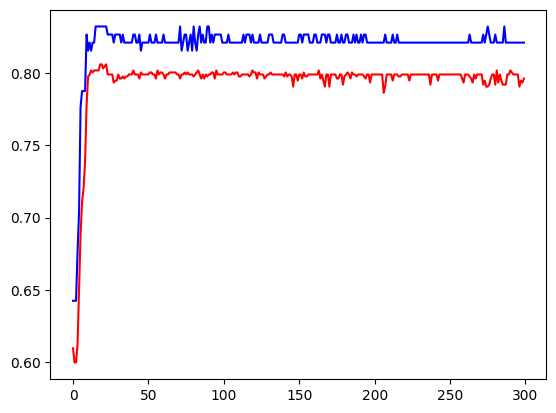

In [46]:
# loss의 변화를 그래프로 그려보아요!
# loss는 epoch이 증가할수록 값이 떨어져요!  (이 값이 상태가 더 좋아요!)
# val_loss epoch이 증가할수록 값이 떨어져요!
# plt.plot(history.history['loss'], color='r')
# plt.plot(history.history['val_loss'], color='b')
# plt.show()

plt.plot(history.history['acc'], color='r')
plt.plot(history.history['val_acc'], color='b')
plt.show()

In [47]:
# Model을 다 만들었으니 이제
# Test 데이터를 이용한 예측결과를 뽑아내서
# 제출파일을 만들어야 해요!

In [55]:
# Test파일의 내용부터 가지고 와요!
test = pd.read_csv('/content/test.csv')
# display(test)
# 필요없는 독립변수(Feature)가 있으면 일단 제거
test1 = test.drop(["PassengerId","Name", "Ticket", "Fare", "Cabin"],
              axis=1,
              inplace=False)
# display(test1.head())
gender_mapping = { "male": 0,
                   "female": 1}
test1['Sex'] = test1['Sex'].map(gender_mapping)
# display(test1.head())
test1['Family'] = test1['SibSp'] + test1['Parch']
test2 = test1.drop(['SibSp', 'Parch'],
               axis=1,
               inplace=False)
# display(test2.head())
test2['Embarked'] = test2['Embarked'].fillna('Q')
# 결측치가 다 채워졌으니 이제 숫자로 변경해보아요!
embarked_mapping = { "S": 0,
                     "C": 1,
                     "Q": 2}
test2['Embarked'] = test2['Embarked'].map(embarked_mapping)
# display(test2.head())
test2['Age'] = test2['Age'].fillna(test2['Age'].mean())
test2.loc[test2['Age'] < 8, 'Age'] = 0
test2.loc[(test2['Age'] >= 8) & (test2['Age'] < 20), 'Age'] = 1
test2.loc[(test2['Age'] >= 20) & (test2['Age'] < 60), 'Age'] = 2
test2.loc[test2['Age'] >= 60, 'Age'] = 3
display(test2.head())

,Pclass,Sex,Age,Embarked,Family
0,3,0,2.0,2,0
1,3,1,2.0,0,1
2,2,0,3.0,2,0
3,3,0,2.0,0,0
4,3,1,2.0,0,2


In [ ]:
x_data_test_norm = scaler.transform(test2.values)

predict = model.predict(x_data_test_norm)
print(predict) # 확률값이 0.5보다 작으면 사망 -> 0으로 처리
               # 확률값이 0.5이상이면 생존 -> 1로 처리

In [61]:
submission = pd.read_csv('/content/gender_submission.csv')
submission['Survived'] = predict
submission['Survived'] = np.where(submission['Survived'] >= 0.5, 1, 0)
display(submission.head())

submission.to_csv('/content/myoutput.csv', index=False)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


In [63]:
# BMI 데이터를 이용한 다중분류 구현
# Multinomial Classification
%reset
# 필요한 module import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Model 구현
from sklearn import linear_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Model 평가
from sklearn.metrics import accuracy_score

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [65]:
# 1. Raw Data Loading
df = pd.read_csv('/content/bmi.csv', skiprows=3)
# display(df.head())
print(df.shape) # (20000, 3)

(20000, 3)


In [70]:
# 데이터 전처리
# 1. 결측치 처리
# df.isnull().sum()  # 결측치가 없어요!
# df.info()
# 2. 이상치 확인 및 처리  # 이상치도 없어요!
# fig = plt.figure()
# ax1 = fig.add_subplot(1,3,1)
# ax2 = fig.add_subplot(1,3,2)
# ax3 = fig.add_subplot(1,3,3)
# ax1.boxplot(df['label'].values)
# ax2.boxplot(df['height'].values)
# ax3.boxplot(df['weight'].values)
# plt.show()
# 3. Feature(독립변수)에 대해서만 정규화를 진행
x_data = df[['height', 'weight']].values  # 2차원
t_data = df['label'].values  # 1차원 => 여기에 있는 값은 분류값.
                             # 따라서 원래 이 값을 one-hot encoding처리해야 해요!
                             # 하지만 tensorflow나 sklearn이 알아서(?) 처리할 수 있어요!
scaler = MinMaxScaler()
scaler.fit(x_data)
x_data_norm = scaler.transform(x_data)
# 4. 모델 평가를 위해서 train과 test데이터를 분리!
x_data_train_norm, x_data_test_norm, t_data_train, t_data_test = \
train_test_split(x_data_norm,
                 t_data,
                 test_size=0.3,
                 stratify=t_data)

In [74]:
# Model 구현(sklearn) - 다중분류 모델 구현
sklearn_model = linear_model.LogisticRegression()
# 학습할때 one-hot encoding으로 종속변수(t_data)를 변환시키지 않고
# 입력했는데 이 값을 sklearn이 알아서 내부적으로 변환시켜서 사용해요!
sklearn_model.fit(x_data_train_norm,
                  t_data_train)
# 예측값 추출
sklearn_predict = sklearn_model.predict(x_data_test_norm)
# 예측값과 test 데이터에 대한 정답을 비교해서 모델의 정확도를 출력!
print(accuracy_score(sklearn_predict, t_data_test))
# 0.985
# 모델이 어느정도 완성되었으니 예측을 해 보아요!
my_status = np.array([[187,85]])
print(sklearn_model.predict_proba(scaler.transform(my_status)))

0.9856666666666667
[[8.59331454e-05 5.20311262e-01 4.79602804e-01]]


In [ ]:
# Tensorflow 구현

keras_model = Sequential()

keras_model.add(Flatten(name='myInput',
                        input_shape=(2,)))
keras_model.add(Dense(units=3,
                      activation='softmax'))
# keras_model.summary()
keras_model.compile(optimizer=Adam(learning_rate=1e-2),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

keras_model.fit(x_data_train_norm,
                t_data_train.reshape(-1,1),
                epochs=200,
                verbose=1,
                validation_split=0.3,
                batch_size=100)

In [81]:
# 모델 평가(Evaluation)
keras_result = keras_model.evaluate(x_data_test_norm,
                                    t_data_test.reshape(-1,1))
print(keras_result) # [0.07532601803541183, 0.9863333106040955]

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9883 - loss: 0.0729
[0.07532601803541183, 0.9863333106040955]


In [82]:
my_status = np.array([[187,85]])
print(keras_model.predict(scaler.transform(my_status)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[1.5711510e-07 4.5961800e-01 5.4038185e-01]]
